<div style="background-color:#EFF5FF; padding:20px; border-radius:10px; border-left:8px solid #0047AB;">

<h1 style="margin-bottom:0;"><b> Optimization Alghorithms </b></h1>



<a id="section-1-imports-and-data-loading"></a>
<div style="background-color:#EFF5FF; padding:20px; border-radius:10px; border-left:8px solid #0047AB;">
<h3><b>1. Imports and Data Loading</b></h3>
</div>

In [23]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('parkinsons_preprocessed.csv')

<a id="section-1-imports-and-data-loading"></a>
<div style="background-color:#EFF5FF; padding:20px; border-radius:10px; border-left:8px solid #0047AB;">
<h3><b>1. Basic Structure</b></h3>
</div>

In [7]:
print("DATASET DIMENSIONS")
print(f"Samples: {df.shape[0]}")
print(f"Features: {df.shape[1]}")

DATASET DIMENSIONS
Samples: 195
Features: 23


In [ ]:
print("Columns:")
for i, col in enumerate(df.columns, 1):
    print(f"   {i}. {col}")

1. DATASET DIMENSIONS
Samples: 195
Features: 23

Columns:
   1. MDVP:Fo(Hz)
   2. MDVP:Fhi(Hz)
   3. MDVP:Flo(Hz)
   4. MDVP:Jitter(%)
   5. MDVP:Jitter(Abs)
   6. MDVP:RAP
   7. MDVP:PPQ
   8. Jitter:DDP
   9. MDVP:Shimmer
   10. MDVP:Shimmer(dB)
   11. Shimmer:APQ3
   12. Shimmer:APQ5
   13. MDVP:APQ
   14. Shimmer:DDA
   15. NHR
   16. HNR
   17. RPDE
   18. DFA
   19. spread1
   20. spread2
   21. D2
   22. PPE
   23. status


<a id="section-1-imports-and-data-loading"></a>
<div style="background-color:#EFF5FF; padding:20px; border-radius:10px; border-left:8px solid #0047AB;">
<h3><b>2. Data Types and Missing Values</b></h3>
</div>

In [9]:
print("DATA TYPES AND MISSING VALUES")
print(df.dtypes)

DATA TYPES AND MISSING VALUES
MDVP:Fo(Hz)         float64
MDVP:Fhi(Hz)        float64
MDVP:Flo(Hz)        float64
MDVP:Jitter(%)      float64
MDVP:Jitter(Abs)    float64
MDVP:RAP            float64
MDVP:PPQ            float64
Jitter:DDP          float64
MDVP:Shimmer        float64
MDVP:Shimmer(dB)    float64
Shimmer:APQ3        float64
Shimmer:APQ5        float64
MDVP:APQ            float64
Shimmer:DDA         float64
NHR                 float64
HNR                 float64
RPDE                float64
DFA                 float64
spread1             float64
spread2             float64
D2                  float64
PPE                 float64
status                int64
dtype: object


In [10]:
print(f"Missing values per column:\n{df.isnull().sum()}")

Missing values per column:
MDVP:Fo(Hz)         0
MDVP:Fhi(Hz)        0
MDVP:Flo(Hz)        0
MDVP:Jitter(%)      0
MDVP:Jitter(Abs)    0
MDVP:RAP            0
MDVP:PPQ            0
Jitter:DDP          0
MDVP:Shimmer        0
MDVP:Shimmer(dB)    0
Shimmer:APQ3        0
Shimmer:APQ5        0
MDVP:APQ            0
Shimmer:DDA         0
NHR                 0
HNR                 0
RPDE                0
DFA                 0
spread1             0
spread2             0
D2                  0
PPE                 0
status              0
dtype: int64


<a id="section-1-imports-and-data-loading"></a>
<div style="background-color:#EFF5FF; padding:20px; border-radius:10px; border-left:8px solid #0047AB;">
<h3><b>3. Target Variable Analysis (status)</b></h3>
</div>

In [14]:
status_counts = df['status'].value_counts()
status_percent = df['status'].value_counts(normalize=True) * 100
for status, count in status_counts.items():
    label = "Parkinson's (1)" if status == 1 else "Healthy (0)"
    print(f"   {label}: {count} samples ({status_percent[status]:.1f}%)")

   Parkinson's (1): 147 samples (75.4%)
   Healthy (0): 48 samples (24.6%)


/var/folders/hg/t7c3gkbj27x28bh9hfhytmph0000gn/T/ipykernel_62465/3511112101.py:5: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[0].set_xticklabels(['Healthy (0)', "Parkinson's (1)"])


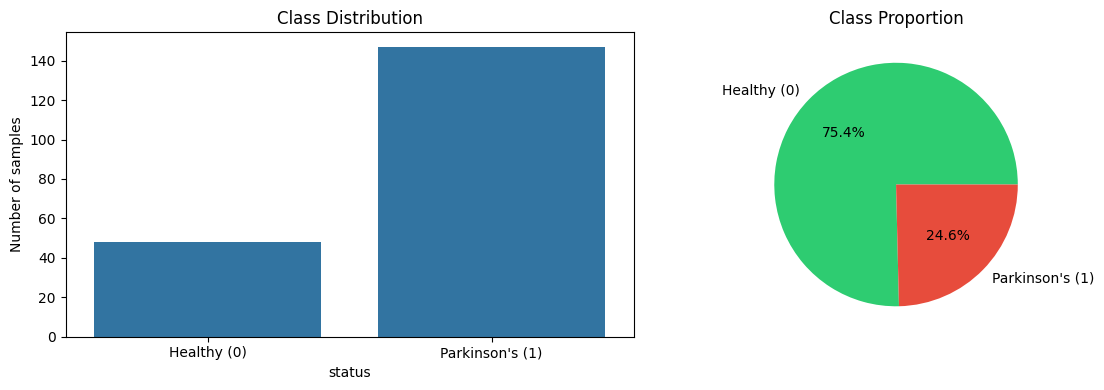

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

sns.countplot(data=df, x='status', ax=axes[0])
axes[0].set_title('Class Distribution')
axes[0].set_xticklabels(['Healthy (0)', "Parkinson's (1)"])
axes[0].set_ylabel('Number of samples')

axes[1].pie(status_counts, labels=['Healthy (0)', "Parkinson's (1)"], 
            autopct='%1.1f%%', colors=['#2ecc71', '#e74c3c'])
axes[1].set_title('Class Proportion')

plt.tight_layout()
plt.savefig('class_distribution.png', dpi=150)
plt.show()

<a id="section-1-imports-and-data-loading"></a>
<div style="background-color:#EFF5FF; padding:20px; border-radius:10px; border-left:8px solid #0047AB;">
<h3><b>4. Descriptive Statistics</b></h3>
</div>

In [17]:
print("DESCRIPTIVE STATISTICS (standardized data)")
feature_cols = [col for col in df.columns if col != 'status']
print(df[feature_cols].describe().round(4))

DESCRIPTIVE STATISTICS (standardized data)
       MDVP:Fo(Hz)  MDVP:Fhi(Hz)  MDVP:Flo(Hz)  MDVP:Jitter(%)  \
count     195.0000      195.0000      195.0000        195.0000   
mean        0.0000       -0.0000        0.0000          0.0000   
std         1.0026        1.0026        1.0026          1.0026   
min        -1.5962       -1.0406       -1.1714         -0.9389   
25%        -0.8879       -0.6821       -0.7379         -0.5709   
50%        -0.1317       -0.2331       -0.2767         -0.2648   
75%         0.6913        0.2970        0.5458          0.2367   
max         2.5646        4.3276        2.8299          5.5710   

       MDVP:Jitter(Abs)  MDVP:RAP  MDVP:PPQ  Jitter:DDP  MDVP:Shimmer  \
count          195.0000  195.0000  195.0000    195.0000      195.0000   
mean             0.0000   -0.0000    0.0000      0.0000        0.0000   
std              1.0026    1.0026    1.0026      1.0026        1.0026   
min             -1.0641   -0.8873   -0.9180     -0.8873       -1.0723 

<a id="section-1-imports-and-data-loading"></a>
<div style="background-color:#EFF5FF; padding:20px; border-radius:10px; border-left:8px solid #0047AB;">
<h3><b>5. Correlation with Target Variable</b></h3>
</div>

In [20]:
print("Top 10 correlated features:")
for feat, corr in correlations.head(10).items():
    strength = "strong" if abs(corr) > 0.5 else "moderate" if abs(corr) > 0.3 else "weak"
    print(f"   {feat:25s}: {corr:+.4f}  ({strength})")

Top 10 correlated features:
   spread1                  : +0.5648  (strong)
   PPE                      : +0.5310  (strong)
   spread2                  : +0.4548  (moderate)
   MDVP:Shimmer             : +0.3674  (moderate)
   MDVP:APQ                 : +0.3643  (moderate)
   Shimmer:APQ5             : +0.3511  (moderate)
   MDVP:Shimmer(dB)         : +0.3507  (moderate)
   Shimmer:APQ3             : +0.3476  (moderate)
   Shimmer:DDA              : +0.3476  (moderate)
   D2                       : +0.3402  (moderate)


Bottom 10 correlated features:
   MDVP:PPQ                 : +0.2887  (weak)
   MDVP:Jitter(%)           : +0.2782  (weak)
   MDVP:RAP                 : +0.2667  (weak)
   Jitter:DDP               : +0.2666  (weak)
   DFA                      : +0.2317  (weak)
   NHR                      : +0.1894  (weak)
   MDVP:Fhi(Hz)             : -0.1661  (weak)
   HNR                      : -0.3615  (moderate)
   MDVP:Flo(Hz)             : -0.3802  (moderate)
   MDVP:Fo(Hz)              : -0.3835  (moderate)


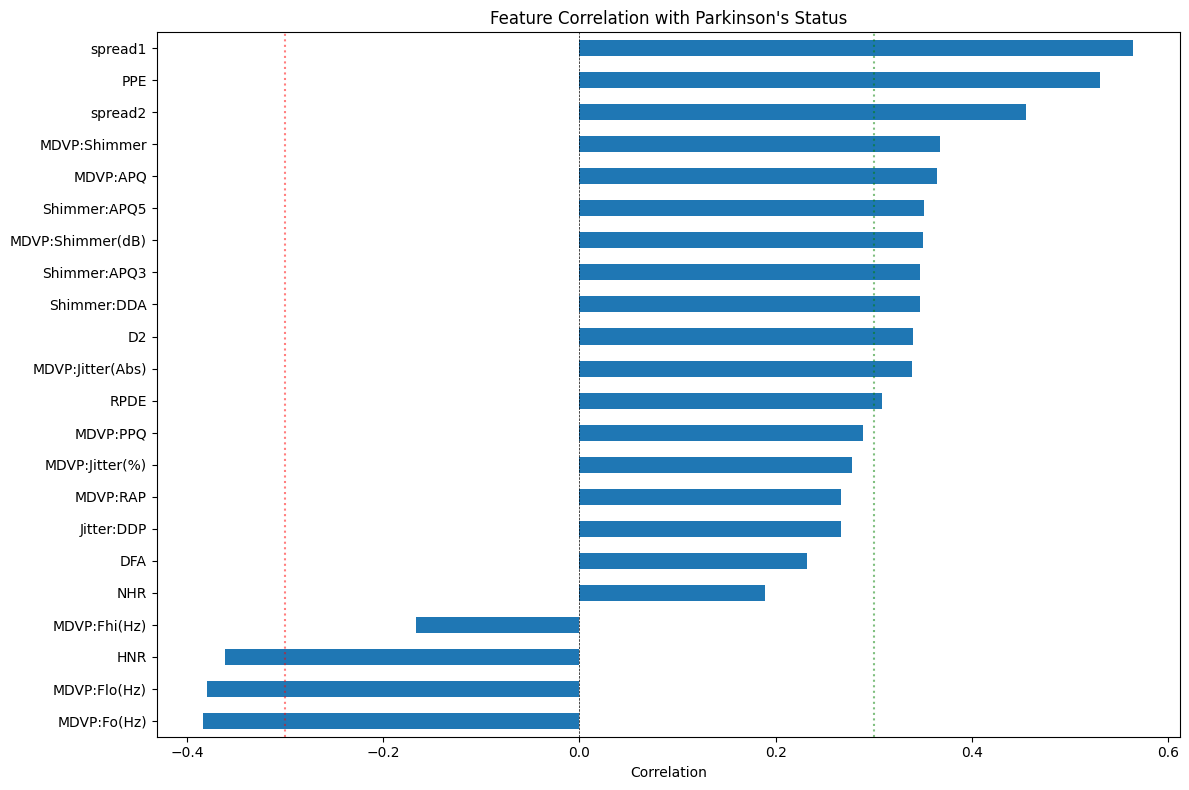

In [22]:
print("Bottom 10 correlated features:")
for feat, corr in correlations.tail(10).items():
    strength = "strong" if abs(corr) > 0.5 else "moderate" if abs(corr) > 0.3 else "weak"
    print(f"   {feat:25s}: {corr:+.4f}  ({strength})")
plt.figure(figsize=(12, 8))
correlations.sort_values().plot(kind='barh')
plt.title('Feature Correlation with Parkinson\'s Status')
plt.xlabel('Correlation')
plt.axvline(x=0, color='black', linestyle='--', linewidth=0.5)
plt.axvline(x=0.3, color='green', linestyle=':', alpha=0.5)
plt.axvline(x=-0.3, color='red', linestyle=':', alpha=0.5)
plt.tight_layout()
plt.savefig('feature_correlations.png', dpi=150)
plt.show()

<a id="section-1-imports-and-data-loading"></a>
<div style="background-color:#EFF5FF; padding:20px; border-radius:10px; border-left:8px solid #0047AB;">
<h3><b>6. Correlation Matrix (Reduced)</b></h3>
</div>


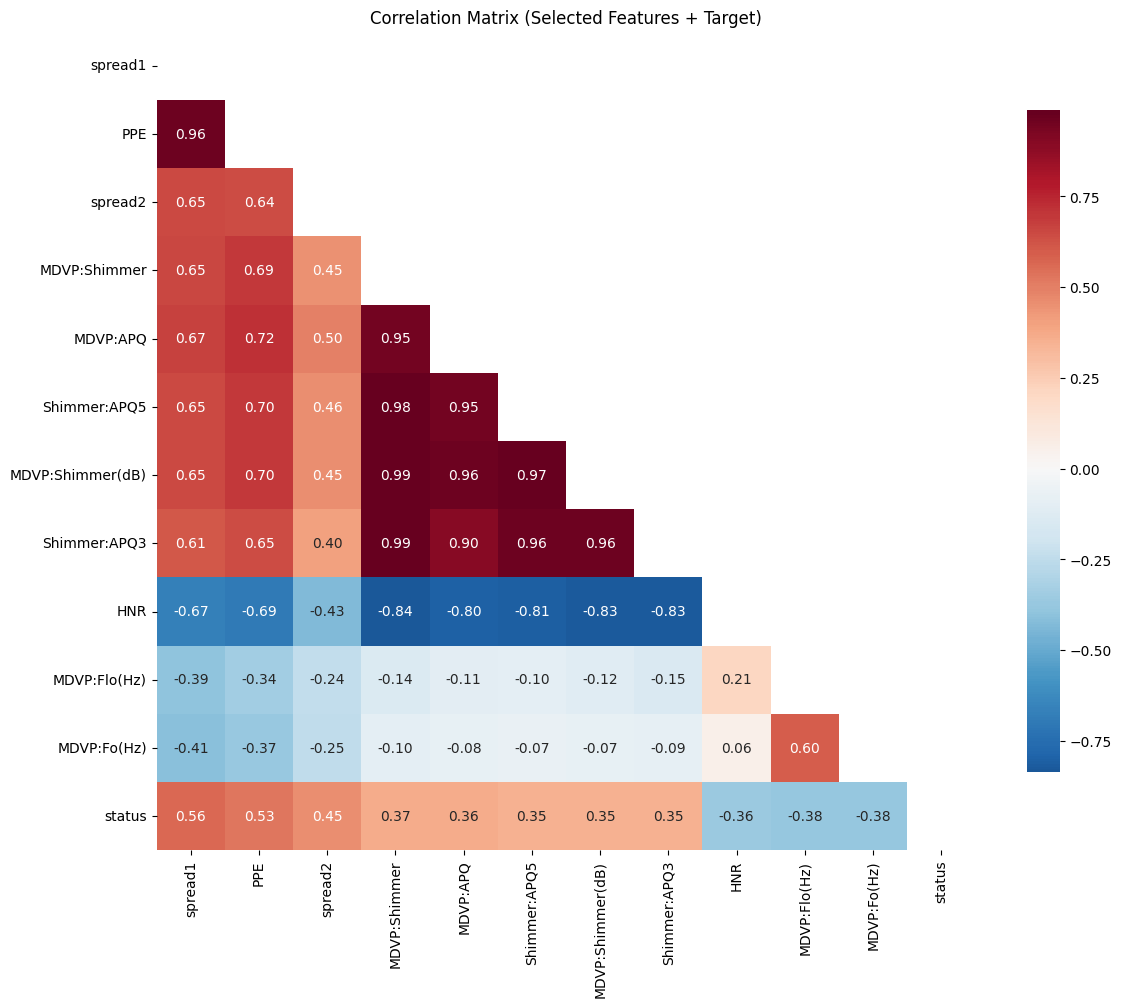

In [25]:
top_features = correlations.head(8).index.tolist() + correlations.tail(3).index.tolist()
corr_matrix = df[top_features + ['status']].corr()

plt.figure(figsize=(12, 10))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, mask=mask, annot=True, fmt='.2f', 
            cmap='RdBu_r', center=0, square=True,
            cbar_kws={"shrink": 0.8})
plt.title('Correlation Matrix (Selected Features + Target)')
plt.tight_layout()
plt.savefig('correlation_matrix.png', dpi=150)
plt.show()

<a id="section-1-imports-and-data-loading"></a>
<div style="background-color:#EFF5FF; padding:20px; border-radius:10px; border-left:8px solid #0047AB;">
<h3><b>7. Feature Distributions</b></h3>
</div>


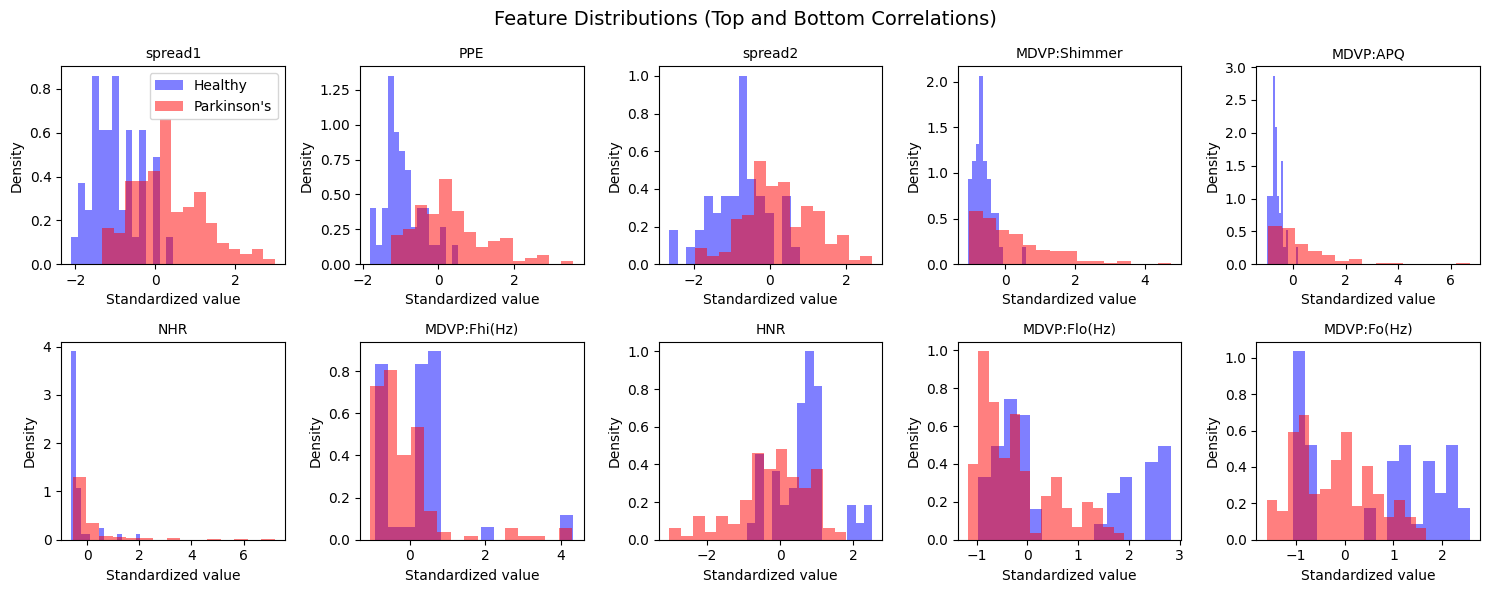

In [26]:
top_5_features = correlations.head(5).index.tolist()
bottom_5_features = correlations.tail(5).index.tolist()
selected_features = top_5_features + bottom_5_features

fig, axes = plt.subplots(2, 5, figsize=(15, 6))
axes = axes.flatten()

for i, feat in enumerate(selected_features):
    for status, color, label in [(0, 'blue', 'Healthy'), (1, 'red', "Parkinson's")]:
        subset = df[df['status'] == status][feat]
        axes[i].hist(subset, bins=15, alpha=0.5, color=color, label=label, density=True)
    axes[i].set_title(feat, fontsize=10)
    axes[i].set_xlabel('Standardized value')
    axes[i].set_ylabel('Density')
    if i == 0:
        axes[i].legend()

plt.suptitle('Feature Distributions (Top and Bottom Correlations)', fontsize=14)
plt.tight_layout()
plt.savefig('feature_distributions.png', dpi=150)
plt.show()

<a id="section-1-imports-and-data-loading"></a>
<div style="background-color:#EFF5FF; padding:20px; border-radius:10px; border-left:8px solid #0047AB;">
<h3><b>8. Outlier Detection</b></h3>
</div>


In [29]:
outlier_counts = {}
for col in feature_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    outliers = ((df[col] < (Q1 - 1.5 * IQR)) | (df[col] > (Q3 + 1.5 * IQR))).sum()
    outlier_counts[col] = outliers

outlier_df = pd.DataFrame(list(outlier_counts.items()), columns=['Feature', 'Outliers'])
outlier_df = outlier_df.sort_values('Outliers', ascending=False)

Features with most outliers:
         Feature  Outliers
             NHR        19
        MDVP:PPQ        15
  MDVP:Jitter(%)        14
        MDVP:RAP        14
      Jitter:DDP        14
    Shimmer:APQ5        13
        MDVP:APQ        12
    MDVP:Fhi(Hz)        11
MDVP:Shimmer(dB)        10
    MDVP:Flo(Hz)         9


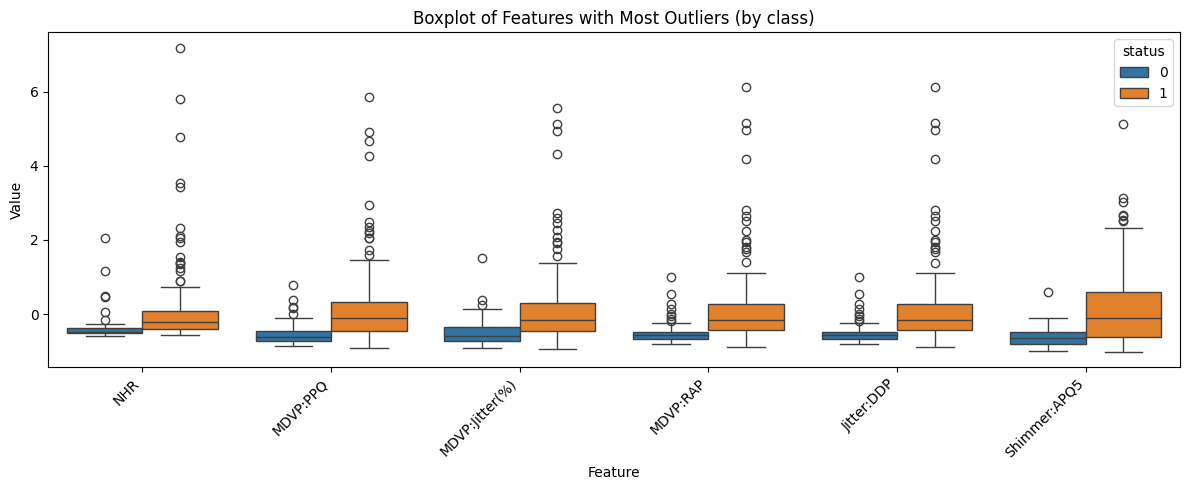

In [30]:
print("Features with most outliers:")
print(outlier_df.head(10).to_string(index=False))

# Boxplot
top_outlier_features = outlier_df.head(6)['Feature'].tolist()

plt.figure(figsize=(12, 5))
df_melted = df.melt(id_vars=['status'], value_vars=top_outlier_features, 
                    var_name='Feature', value_name='Value')
sns.boxplot(data=df_melted, x='Feature', y='Value', hue='status')
plt.title('Boxplot of Features with Most Outliers (by class)')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig('outliers_boxplot.png', dpi=150)
plt.show()

<a id="section-1-imports-and-data-loading"></a>
<div style="background-color:#EFF5FF; padding:20px; border-radius:10px; border-left:8px solid #0047AB;">
<h3><b>8. Variance Analysis</b></h3>
</div>